-----SADECE TEMEL AJANLAR VARSA---------

Modelimizi sadece temel ajanların ve haber etkisinin olduğu bir piyasa yapısı olarak tanımladık. Ajanların kararları, haberin pozitif ya da negatif oluşuna, kendi haber duyarlılıklarına ve riskten kaçınma düzeylerine göre şekilleniyor. Bu yapı, teknik ya da gürültü etkilerinden arındırılmış bir temel değer odaklı piyasa davranışı sağlar.

In [ ]:

!pip install mesa[rec]
!pip install seaborn

# Has multi-dimensional arrays and matrices.
# Has a large collection of mathematical functions to operate on these arrays.
import numpy as np

# Data manipulation and analysis.
import pandas as pd

# Data visualization tools.
import seaborn as sns

import mesa


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 469.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.0/197.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.8/265.8 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 454.8/454.8 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 52.7 MB/s eta 0:00:00


Haber: 1
  Agent 1: Haber: 1, Sensitivity: 0.48, Expected Return: 0.48, Risk Aversion: 0.59
    Agent 1 Beklemede
  Agent 2: Haber: 1, Sensitivity: 0.36, Expected Return: 0.36, Risk Aversion: 0.77
    Agent 2 Beklemede
  Agent 3: Haber: 1, Sensitivity: 0.19, Expected Return: 0.19, Risk Aversion: 0.57
    Agent 3 Beklemede
  Agent 4: Haber: 1, Sensitivity: 0.43, Expected Return: 0.43, Risk Aversion: 0.70
    Agent 4 Beklemede
  Agent 5: Haber: 1, Sensitivity: 0.83, Expected Return: 0.83, Risk Aversion: 0.42
    Agent 5 Alım Yaptı: 10 hisse @ 100.00
  Agent 6: Haber: 1, Sensitivity: 0.78, Expected Return: 0.78, Risk Aversion: 0.48
    Agent 6 Alım Yaptı: 10 hisse @ 100.00
  Agent 7: Haber: 1, Sensitivity: 0.85, Expected Return: 0.85, Risk Aversion: 0.83
    Agent 7 Alım Yaptı: 10 hisse @ 100.00
  Agent 8: Haber: 1, Sensitivity: 0.69, Expected Return: 0.69, Risk Aversion: 0.73
    Agent 8 Beklemede
  Agent 9: Haber: 1, Sensitivity: 0.65, Expected Return: 0.65, Risk Aversion: 0.76
    Agen

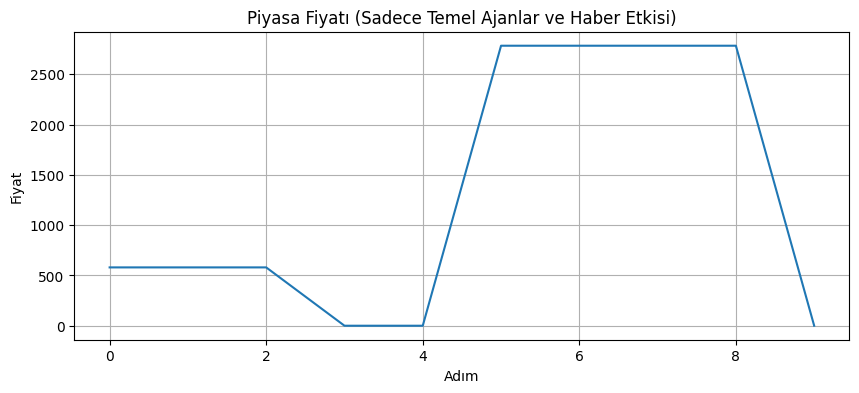

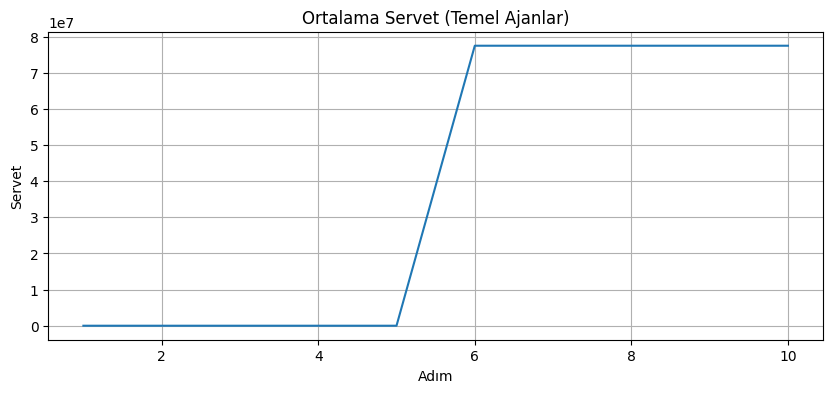

In [ ]:
# Temel Ajanlar ve Haber Etkisi ile Evrimsel Piyasa Modeli


from mesa.datacollection import DataCollector
import random
import numpy as np
import matplotlib.pyplot as plt
################################################################################
"""
    Haberlerin rastgele olarak üretildiği ortamı simüle eder.
    news_prob: Haber gelme olasılığı.
    current_news: Mevcut haberin değeri (-1, 0, veya 1).
    step(): Her adımda yeni bir haber üretir.
"""

class NewsEnvironment:
    def __init__(self, news_prob=0.7):
        self.news_prob = news_prob  # haberin geldiği olasılık
        self.current_news = 0       # -1 (negatif), 0 (nötr), 1 (pozitif)

    def step(self):
        roll = random.random()
        if roll < self.news_prob:
            self.current_news = random.choice([-1, 1])
        else:
            self.current_news = 0
        return self.current_news

################################################################################
"""
    Piyasada işlem yapan temel ajanı temsil eder.

    risk_aversion: Ajanın riskten kaçınma seviyesi.

    sensitivity: Ajanın habere duyarlılığı.

    step(): Her adımda ajan haberlere göre alım veya satım kararı alır.

    get_wealth(): Ajanın toplam servetini hesaplar.
"""


class FundamentalAgent(mesa.Agent):
    def __init__(self, model, risk_aversion, sensitivity):
        super().__init__(model)
        self.cash = 1000
        self.shares = 0
        self.risk_aversion = risk_aversion  # [0, 1]
        self.sensitivity = sensitivity      # haber duyarlılığı [0, 1]
        self.last_trade_amount = 0 # Son işlem miktarını tutacak yeni attribute eklendi


    def step(self):
        news = self.model.news.current_news
        price = self.model.price  # Mevcut fiyatı adım başında al

        expected_return = news * self.sensitivity

        # Her ajan için beklenen getiri ve riskten kaçınma yazdırılıyor
        print(f"  Agent {self.unique_id}: Haber: {news}, Sensitivity: {self.sensitivity:.2f}, Expected Return: {expected_return:.2f}, Risk Aversion: {self.risk_aversion:.2f}")

        shares_to_trade = 0
        self.last_trade_amount = 0 # Her adım başında son işlem miktarını sıfırla

        # Karar mekanizması: risk duyarlılığına göre al/sat
        if expected_return > self.risk_aversion:
            # Alım yap
            max_buy_shares = (self.cash) // price if price > 0 else 0
            shares_to_trade = max_buy_shares

            if shares_to_trade > 0:
                self.shares += shares_to_trade
                self.cash -= shares_to_trade * price
                self.last_trade_amount = shares_to_trade # Yapılan alım miktarını kaydet
                print(f"    Agent {self.unique_id} Alım Yaptı: {shares_to_trade} hisse @ {price:.2f}")


        elif expected_return < -self.risk_aversion:
            # Satış yap
            shares_to_trade = int(self.shares )

            if shares_to_trade > 0:
                self.cash += shares_to_trade * price
                self.shares -= shares_to_trade
                self.last_trade_amount = -shares_to_trade # Yapılan satım miktarını negatif olarak kaydet
                print(f"    Agent {self.unique_id} Satım Yaptı: {shares_to_trade} hisse @ {price:.2f}")
        else:
            print(f"    Agent {self.unique_id} Beklemede")


    def get_wealth(self):
        return self.cash + self.shares * self.model.price

################################################################################
"""
    Piyasa ortamını ve ajanların etkileşimini simüle eder.
    N: Ajan sayısı.
    price: Başlangıç fiyatı.
    news_prob: Haber gelme olasılığı.
    step(): Her adımda haberler üretilir, ajanlar karar alır ve fiyat güncellenir.
    update_price(): Piyasa fiyatını arz ve talebe göre günceller.
"""

class NewsMarketModel(mesa.Model):
    def __init__(self, N=50, price=100, news_prob=0.3):
        super().__init__()

        self.num_agents = N

        self.price = price
        self.price_history = []
        self.news = NewsEnvironment(news_prob=news_prob)

        self.datacollector = DataCollector(
            model_reporters={"Price": lambda m: m.price},
            agent_reporters={"Wealth": lambda a: a.get_wealth()}
        )

        for i in range(self.num_agents):
            risk = random.uniform(0.1, 0.9)
            sens = random.uniform(0.1, 0.9)
            # Agent Unique ID için model.next_id() kullanıyoruz
            agent = FundamentalAgent(self, risk, sens)
            self.agents.add(agent) # Schedule'a ekliyoruz

    def step(self):
        # Adım numarasını yazdır
        #print(f"-------- Adım: {self.agents.steps + 1} ---------")
        self.news.step()
        # Haber değerini yazdır
        print(f"Haber: {self.news.current_news}")

        self.agents.do("step") # Ajanların adımını çalıştırıyoruz
        self.update_price()
        self.datacollector.collect(self)

    def update_price(self):
        net_demand = sum([a.last_trade_amount for a in self.agents if hasattr(a, 'last_trade_amount')])
        # Net talep değerini yazdır
        print(f"Net Talep: {net_demand}")

        price_change_percentage = net_demand * 0.01
        new_price = self.price * (1 + price_change_percentage)

        new_price = max(0.1, new_price)

        self.price = new_price
        self.price_history.append(new_price)
        # Güncel fiyatı yazdır (isteğe bağlı)
        print(f"Güncel Fiyat: {self.price:.2f}")


################################################################################
"""
    NewsMarketModel sınıfından bir model nesnesi oluşturulur.
    Simülasyon belirli sayıda adım için çalıştırılır.
    Toplanan veriler kullanılarak piyasa fiyatı ve ortalama servet grafikleri çizdirilir.

"""

# Simülasyonu çalıştıralım
model = NewsMarketModel(N=100, price=100, news_prob=0.7)
# Daha az adım çalıştırarak çıktıyı yönetebilirsiniz
for i in range(10): # Örneğin sadece ilk 10 adımı yazdır
    model.step()

# Sonuçları gösterelim (grafikler için tam simülasyonu çalıştırabilirsiniz, yukarıdaki döngü kısa tutuldu)
# model = NewsMarketModel(N=100, price=100, news_prob=0.7)
# for i in range(100):
#     model.step()


data = model.datacollector.get_model_vars_dataframe()
agent_data = model.datacollector.get_agent_vars_dataframe()

plt.figure(figsize=(10, 4))
plt.plot(data["Price"])
plt.title("Piyasa Fiyatı (Sadece Temel Ajanlar ve Haber Etkisi)")
plt.xlabel("Adım")
plt.ylabel("Fiyat")
plt.grid(True)
plt.show()

# Ortalama servet
if not agent_data.empty: # Boş DataFrame durumunu kontrol et
    yeni_df = agent_data.reset_index()
    average_wealth = yeni_df.groupby("Step")["Wealth"].mean()
    plt.figure(figsize=(10, 4))
    plt.plot(average_wealth)
    plt.title("Ortalama Servet (Temel Ajanlar)")
    plt.xlabel("Adım")
    plt.ylabel("Servet")
    plt.grid(True)
    plt.show()
else:
    print("Ajan verisi toplanamadı, ortalama servet grafiği çizilemiyor.")